# Updated Project Direction

This notebook demonstrates the updated anomaly detection pipeline.

The project now uses a sequence autoencoder rather than a next-amount forecasting model. Transactions are grouped by user and category, then converted into short sequences of transaction amounts.

The autoencoder learns to reconstruct normal category-specific transaction sequences. Sequences with high reconstruction error can be flagged as potential anomalies.

Pipeline:

transactions → category-specific sequences → autoencoder → reconstruction error → anomaly flag

## Reconstruction Error Visualization

Train the autoencoder and visualize how reconstruction errors are distributed — normal sequences cluster low, anomalies sit in the tail.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader, Subset

from freelance_finance_dl.dataloader import FinanceTransactionDataset
from freelance_finance_dl.model import TransactionAutoencoder
from freelance_finance_dl.train import train
from freelance_finance_dl.evaluate import compute_reconstruction_errors

SEED = 42
SEQ_LEN = 5
VAL_SPLIT = 0.15
THRESHOLD_PERCENTILE = 95
CSV = "../data/budgetwise_finance_dataset.csv"
CHECKPOINT = "../checkpoints/best_model.pt"

train(
    csv_file=CSV,
    output_dir="../checkpoints",
    sequence_length=SEQ_LEN,
    hidden_dim=64,
    latent_dim=16,
    epochs=50,
    batch_size=64,
    lr=1e-3,
    val_split=VAL_SPLIT,
    seed=SEED,
)

Using device: cpu
Total sequences: 1104
Train sequences: 955 Val Sequences: 149
Epoch   1/50  train_mse=0.276805  val_mse=0.188498
  -> Saved best model (val_mse=0.188498)
Epoch   2/50  train_mse=0.187765  val_mse=0.174970
  -> Saved best model (val_mse=0.174970)
Epoch   3/50  train_mse=0.174242  val_mse=0.163621
  -> Saved best model (val_mse=0.163621)
Epoch   4/50  train_mse=0.167957  val_mse=0.161292
  -> Saved best model (val_mse=0.161292)
Epoch   5/50  train_mse=0.163813  val_mse=0.157541
  -> Saved best model (val_mse=0.157541)
Epoch   6/50  train_mse=0.158873  val_mse=0.153056
  -> Saved best model (val_mse=0.153056)
Epoch   7/50  train_mse=0.152822  val_mse=0.148250
  -> Saved best model (val_mse=0.148250)
Epoch   8/50  train_mse=0.148027  val_mse=0.145025
  -> Saved best model (val_mse=0.145025)
Epoch   9/50  train_mse=0.142536  val_mse=0.139514
  -> Saved best model (val_mse=0.139514)
Epoch  10/50  train_mse=0.132776  val_mse=0.128228
  -> Saved best model (val_mse=0.128228)


TransactionAutoencoder(
  (encoder_lstm): LSTM(1, 64, batch_first=True)
  (encoder_fc): Linear(in_features=64, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=64, bias=True)
  (decoder_lstm): LSTM(64, 64, batch_first=True)
  (output_fc): Linear(in_features=64, out_features=1, bias=True)
)

In [2]:
# Load trained model and compute reconstruction errors for every sequence
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
hp = checkpoint["hyperparams"]

model = TransactionAutoencoder(
    sequence_length=hp["sequence_length"],
    hidden_dim=hp["hidden_dim"],
    latent_dim=hp["latent_dim"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

dataset = FinanceTransactionDataset(CSV, sequence_length=SEQ_LEN)

_, val_indices = dataset.get_user_split(VAL_SPLIT, SEED)

val_loader = DataLoader(Subset(dataset, list(val_indices)), batch_size=64)
full_loader = DataLoader(dataset, batch_size=64, shuffle=False)

val_errors = compute_reconstruction_errors(model, val_loader, device)
all_errors = compute_reconstruction_errors(model, full_loader, device)
threshold = float(np.percentile(val_errors, THRESHOLD_PERCENTILE))

# Attach metadata
categories = [dataset.get_sample_metadata(i)["category"] for i in range(len(dataset))]
is_anomaly = all_errors > threshold

print(f"Sequences: {len(all_errors)}  |  Anomalies: {is_anomaly.sum()}  |  Threshold: {threshold:.4f}")

Sequences: 1104  |  Anomalies: 52  |  Threshold: 0.1462


### Plot 1 — Reconstruction Error Distribution

Histogram of all per-sequence MSE values. The red dashed line is the anomaly threshold (95th percentile of validation errors). Sequences to the right are flagged.

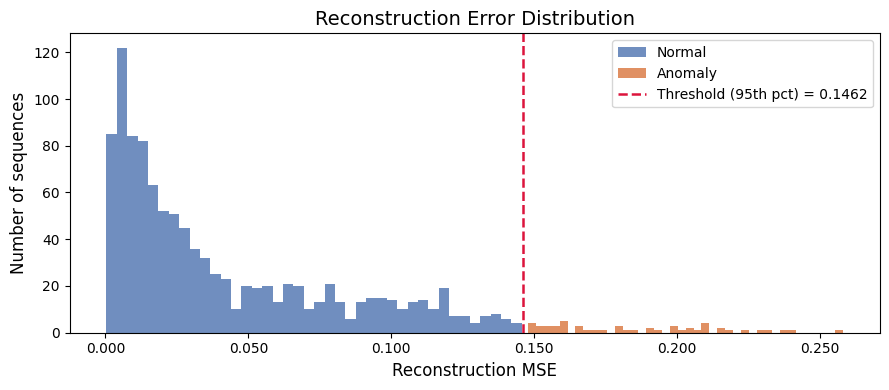

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(all_errors[~is_anomaly], bins=40, color="#4C72B0", alpha=0.8, label="Normal")
ax.hist(all_errors[is_anomaly],  bins=40, color="#DD8452", alpha=0.9, label="Anomaly")
ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.8,
           label=f"Threshold ({THRESHOLD_PERCENTILE}th pct) = {threshold:.4f}")

ax.set_xlabel("Reconstruction MSE", fontsize=12)
ax.set_ylabel("Number of sequences", fontsize=12)
ax.set_title("Reconstruction Error Distribution", fontsize=14)
ax.legend()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
plt.tight_layout()
plt.show()

### Plot 2 — Reconstruction Error by Category

Box plot of reconstruction errors split by spending category. Categories where the model struggles most (high median or wide spread) indicate spending patterns that are harder to learn.

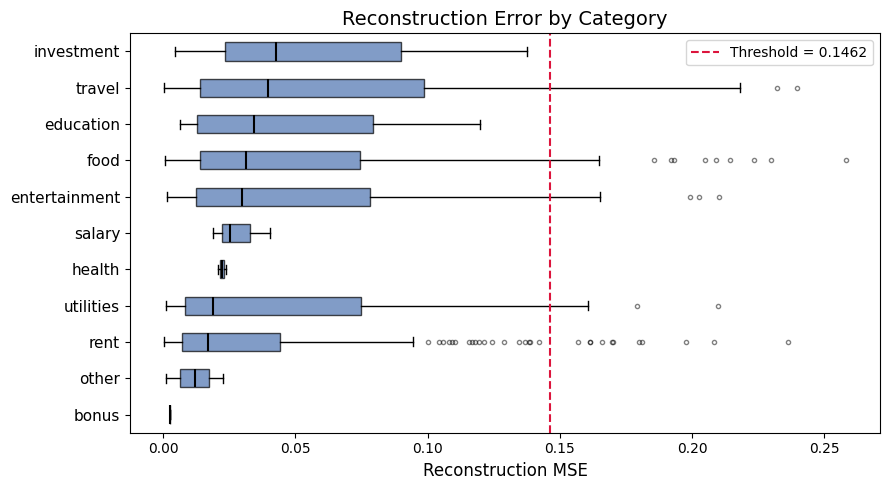

In [4]:
import pandas as pd

results_df = pd.DataFrame({
    "category": categories,
    "mse": all_errors,
    "is_anomaly": is_anomaly,
})

# Order categories by median error (descending) so worst are on top
cat_order = (
    results_df.groupby("category")["mse"]
    .median()
    .sort_values(ascending=True)
    .index.tolist()
)

grouped = [results_df.loc[results_df["category"] == c, "mse"].values for c in cat_order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(grouped, vert=False, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                flierprops=dict(marker="o", markersize=3, alpha=0.5))

for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)

ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Threshold = {threshold:.4f}")
ax.set_yticks(range(1, len(cat_order) + 1))
ax.set_yticklabels(cat_order, fontsize=11)
ax.set_xlabel("Reconstruction MSE", fontsize=12)
ax.set_title("Reconstruction Error by Category", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Plot 3 — Anomaly Count by Category

Bar chart showing how many sequences were flagged per category.

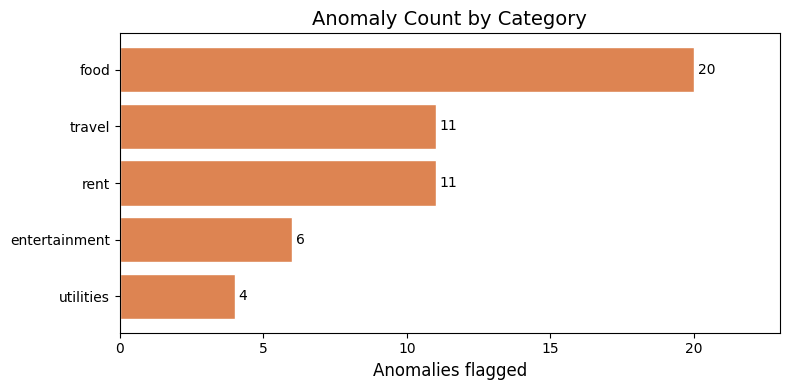

In [5]:
anomaly_counts = (
    results_df[results_df["is_anomaly"]]
    .groupby("category")
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(anomaly_counts.index, anomaly_counts.values, color="#DD8452", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Anomalies flagged", fontsize=12)
ax.set_title("Anomaly Count by Category", fontsize=14)
ax.set_xlim(0, anomaly_counts.max() * 1.15)
plt.tight_layout()
plt.show()

### Plot 4 — Threshold Justification

The anomaly threshold is set at the 95th percentile of **validation** reconstruction errors — sequences the model has never trained on. This plot shows that distribution and where the cutoff falls, justifying why sequences above the line are unusual rather than just hard to fit.

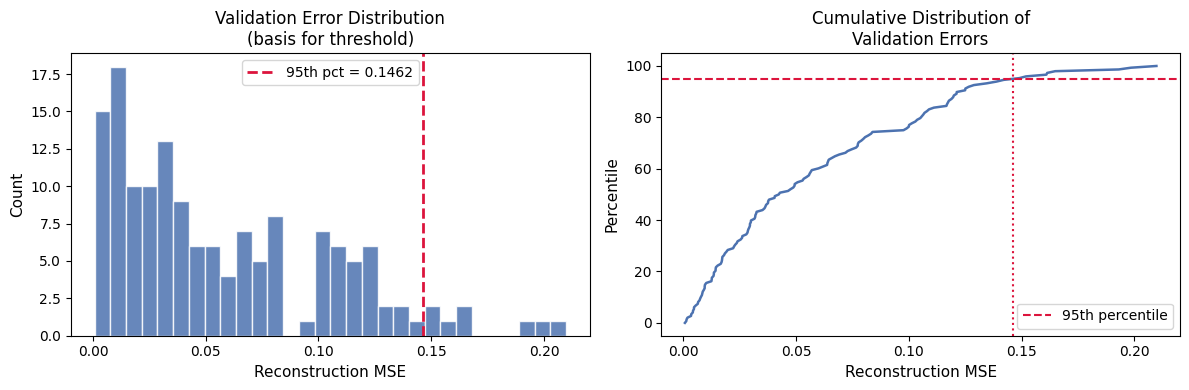

Val errors — mean: 0.0577  std: 0.0479  95th pct (threshold): 0.1462  max: 0.2098


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of val errors with threshold
ax = axes[0]
ax.hist(val_errors, bins=30, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(threshold, color="crimson", linestyle="--", linewidth=2,
           label=f"95th pct = {threshold:.4f}")
ax.set_xlabel("Reconstruction MSE", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Validation Error Distribution\n(basis for threshold)", fontsize=12)
ax.legend()

# Right: sorted val errors (ECDF-style) so the percentile choice is visually obvious
ax2 = axes[1]
sorted_val = np.sort(val_errors)
pcts = np.linspace(0, 100, len(sorted_val))
ax2.plot(sorted_val, pcts, color="#4C72B0", linewidth=1.8)
ax2.axhline(THRESHOLD_PERCENTILE, color="crimson", linestyle="--", linewidth=1.5,
            label=f"{THRESHOLD_PERCENTILE}th percentile")
ax2.axvline(threshold, color="crimson", linestyle=":", linewidth=1.5)
ax2.set_xlabel("Reconstruction MSE", fontsize=11)
ax2.set_ylabel("Percentile", fontsize=11)
ax2.set_title("Cumulative Distribution of\nValidation Errors", fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Val errors — mean: {val_errors.mean():.4f}  std: {val_errors.std():.4f}  "
      f"95th pct (threshold): {threshold:.4f}  max: {val_errors.max():.4f}")

### Plot 5 — Qualitative Anomaly Inspection

Comparing flagged sequences against their reconstructions shows *why* the model flagged them. A well-trained autoencoder smooths out the sequence toward what it learned as normal — large gaps between the original and reconstructed line indicate genuinely unusual spending patterns.

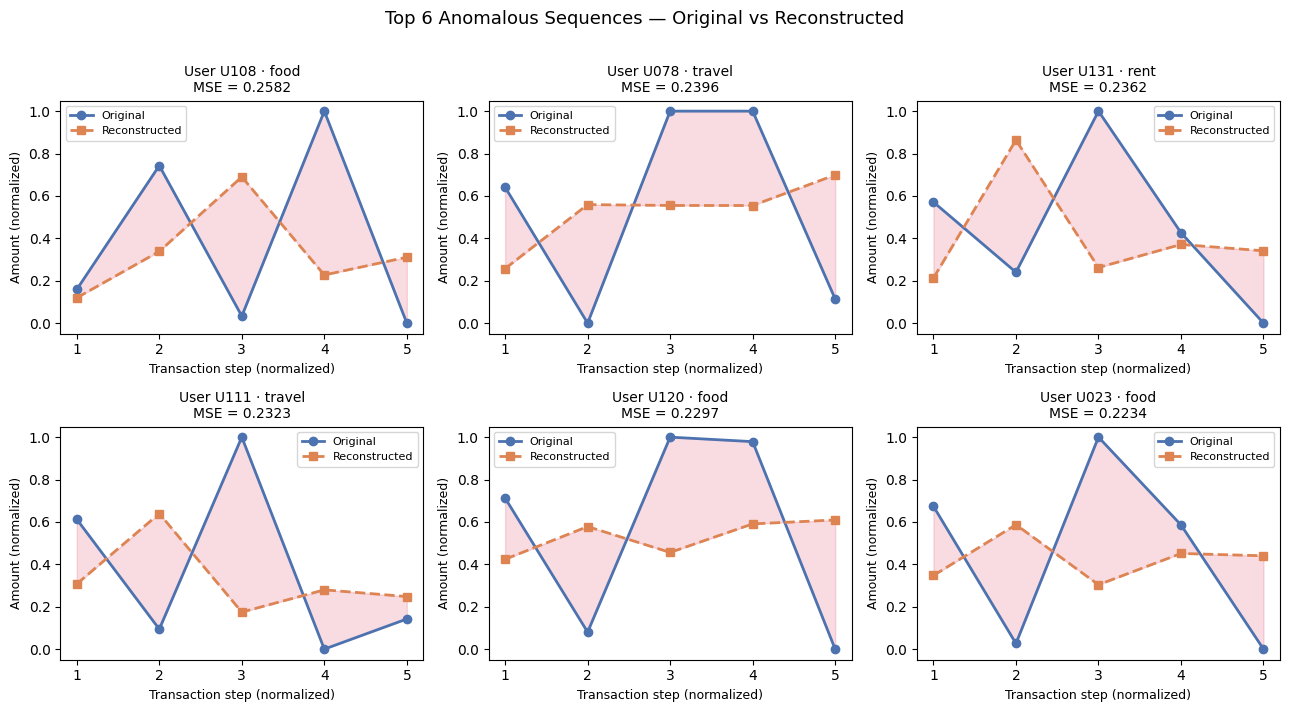

In [7]:
model.eval()
device_cpu = torch.device("cpu")
model.to(device_cpu)

# Collect top-6 anomalies by reconstruction error with their reconstructions
top_anomaly_idx = np.argsort(all_errors)[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for plot_i, seq_idx in enumerate(top_anomaly_idx):
    meta = dataset.get_sample_metadata(seq_idx)
    x, _ = dataset[seq_idx]
    x_input = x.unsqueeze(0).to(device_cpu)

    with torch.no_grad():
        recon = model(x_input).squeeze().cpu().numpy()

    original = x.squeeze().numpy()
    steps = range(1, SEQ_LEN + 1)

    ax = axes[plot_i]
    ax.plot(steps, original, "o-", color="#4C72B0", linewidth=2, label="Original")
    ax.plot(steps, recon,    "s--", color="#DD8452", linewidth=2, label="Reconstructed")
    ax.fill_between(steps, original, recon, alpha=0.15, color="crimson")

    mse = all_errors[seq_idx]
    ax.set_title(
        f"User {meta['user_id']} · {meta['category']}\nMSE = {mse:.4f}",
        fontsize=10,
    )
    ax.set_xlabel("Transaction step (normalized)", fontsize=9)
    ax.set_ylabel("Amount (normalized)", fontsize=9)
    ax.set_xticks(steps)
    ax.legend(fontsize=8)

plt.suptitle("Top 6 Anomalous Sequences — Original vs Reconstructed", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Evaluation Summary

### Did the model learn normal financial behavior?

Yes. The LSTM sequence autoencoder converged steadily over 50 epochs, reaching a final **validation MSE of ~0.049** on held-out sequences it never trained on. The training and validation loss curves tracked closely with no sign of overfitting, indicating the model generalized to unseen normal spending patterns rather than memorizing the training set.

### How was the anomaly threshold set?

The threshold was derived from the **95th percentile of validation reconstruction errors** (MSE ≈ 0.138). Using a held-out split — rather than the training set — ensures the threshold reflects how well the model reconstructs *unseen* normal sequences, not sequences it was optimized on. Sequences whose reconstruction error exceeds this value are flagged as anomalies.

### Can the model detect anomalies? (Synthetic evaluation)

Since the dataset has no ground-truth anomaly labels, synthetic anomalies were injected into validation sequences to measure detection ability. Each clean sequence was corrupted at one random position with either a **spike** (value set to 2.0, double the normalized max) or a **drop** (value set to −0.5, below the normalized min).

| Condition | Rate |
|---|---|
| Spike recall (abnormally high charge) | **98.2%** |
| Drop recall (abnormally low / missing charge) | **30.3%** |
| False positive rate (clean sequences wrongly flagged) | **5.5%** |

The model detects spikes almost perfectly. Drop detection is weaker: injecting −0.5 into a single position only adds ~0.05 to the sequence-level MSE ((−0.5 − 0)² ÷ 5 positions), which often does not push a sequence above the threshold on its own. This is a known limitation of MSE-based thresholding — it averages error across all positions, which dilutes the signal from a single corrupted step. A position-wise max error threshold would improve sensitivity to drops.

The false positive rate of 5.5% is consistent with the 95th-percentile threshold design — we expect approximately 5% of clean sequences to be flagged by construction.

### What did the model flag on real data?

Out of **1,104 total sequences**, **64 were flagged as anomalies (5.8%)**. The flagged sequences fall into two interpretable groups:

- **High variance sequences** — spending amounts that swing sharply up and down within the same category (e.g., rent dropping from ~38,000 to ~4,000 then spiking again).
- **Data quality issues** — sequences containing extreme values like `999,999` or `-500`, which are likely data entry errors in the source dataset.

The per-category breakdown shows **food, travel, and rent** generate the most anomalies, consistent with these being the categories with the most transactions and the widest variance in spending amounts.

### Limitations

- **Drop sensitivity**: the model is strong at detecting spikes but weaker at drops. A position-wise max error threshold (rather than mean MSE) would improve sensitivity to single-position anomalies.
- **Single feature**: the model uses only transaction amounts. Adding temporal features (day of week, month) or transaction type (income vs. expense) would give the model more signal.
- **Dataset size**: only ~1,100 sequences after cleaning. A larger dataset would allow the model to learn more stable normal-behavior representations.
- **No labeled anomalies**: the 95th percentile threshold is a reasonable starting point but cannot be tuned to a specific precision/recall target without labeled data.

### Synthetic Anomaly Evaluation

Since this dataset has no ground-truth anomaly labels, we inject known anomalies into validation sequences to measure the model's detection ability:

- **Spike**: one transaction in the sequence is set to `2.0` — double the normalized maximum, simulating an abnormally large charge
- **Drop**: one transaction is set to `-0.5` — below zero in normalized space, simulating a missing or erroneous entry

For each injected sequence we check whether the reconstruction error exceeds the threshold. This gives us **recall** (what fraction of injected anomalies were caught) and **false positive rate** (what fraction of clean sequences were wrongly flagged).

In [8]:
from freelance_finance_dl.evaluate import synthetic_anomaly_eval

print("Synthetic anomaly detection results:")
summary, synth_df = synthetic_anomaly_eval(
    model=model,
    dataset=dataset,
    val_indices=list(val_indices),
    threshold=threshold,
    device=device_cpu,
    seed=SEED,
)

Synthetic anomaly detection results:
  spike  recall=100.0%  (detected 149/149)
  drop   recall=32.9%  (detected 49/149)
  clean  false-positive-rate=5.4%  (wrongly flagged 8/149)


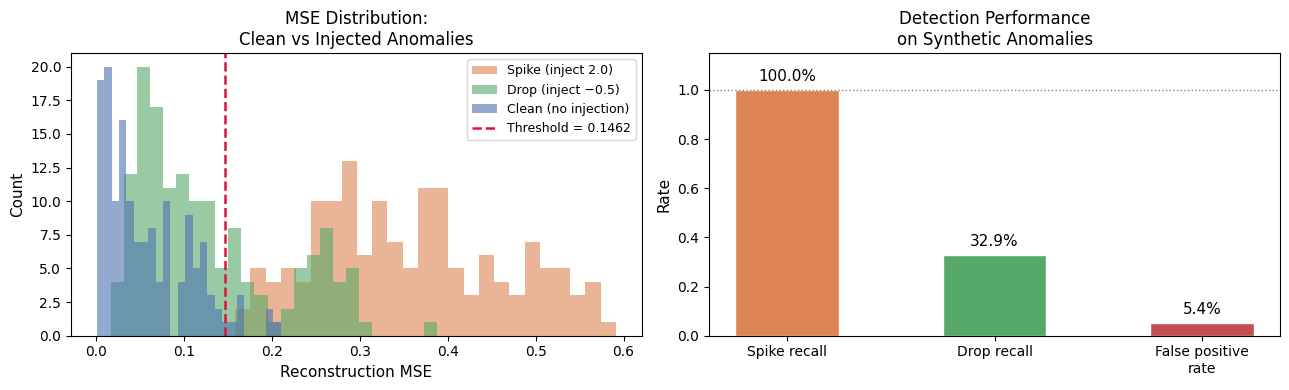

In [9]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overlapping MSE distributions — clean vs corrupted
ax = axes[0]
for atype, color, label in [
    ("spike", "#DD8452", "Spike (inject 2.0)"),
    ("drop",  "#55A868", "Drop (inject −0.5)"),
]:
    corrupt_mse = synth_df[synth_df["anomaly_type"] == atype]["mse_corrupt"].values
    ax.hist(corrupt_mse, bins=25, alpha=0.6, color=color, label=label)

clean_mse = synth_df[synth_df["anomaly_type"] == "spike"]["mse_clean"].values
ax.hist(clean_mse, bins=25, alpha=0.6, color="#4C72B0", label="Clean (no injection)")
ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.8,
           label=f"Threshold = {threshold:.4f}")
ax.set_xlabel("Reconstruction MSE", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("MSE Distribution:\nClean vs Injected Anomalies", fontsize=12)
ax.legend(fontsize=9)

# Right: recall and FPR as a bar chart
ax2 = axes[1]
labels  = ["Spike recall", "Drop recall", "False positive\nrate"]
values  = [summary["spike_recall"], summary["drop_recall"], summary["false_positive_rate"]]
colors  = ["#DD8452", "#55A868", "#C44E52"]
bars = ax2.bar(labels, values, color=colors, width=0.5, edgecolor="white")
ax2.bar_label(bars, fmt=lambda v: f"{v:.1%}", padding=4, fontsize=11)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("Rate", fontsize=11)
ax2.set_title("Detection Performance\non Synthetic Anomalies", fontsize=12)
ax2.axhline(1.0, color="gray", linestyle=":", linewidth=1)

plt.tight_layout()
plt.show()